In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

plt.figure(figsize=(12,6))

sns.set_style("whitegrid")

<Figure size 1200x600 with 0 Axes>

In [ ]:
nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

cat = pd.read_csv(
    "../data/raw/05_category_inflows.csv"
)

folios = pd.read_csv(
    "../data/raw/06_industry_folio_count.csv"
)

tx = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

funds = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

Task - 1

In [ ]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

daily_nav = (
    nav.groupby("date")["nav"]
       .mean()
       .reset_index()
)



In [5]:
fig = px.line(
    daily_nav,
    x="date",
    y="nav",
    title="Average Daily NAV (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.15
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    annotation_text="2024 Correction",
    fillcolor="red",
    opacity=0.15
)

fig.show()

Insight : Average NAVs rose significantly during 2023, indicating a broad market bull phase, followed by temporary corrections during 2024.

Task 2 : 

In [6]:
aum["date"] = pd.to_datetime(
    aum["date"]
)

aum["year"] = (
    aum["date"].dt.year
)

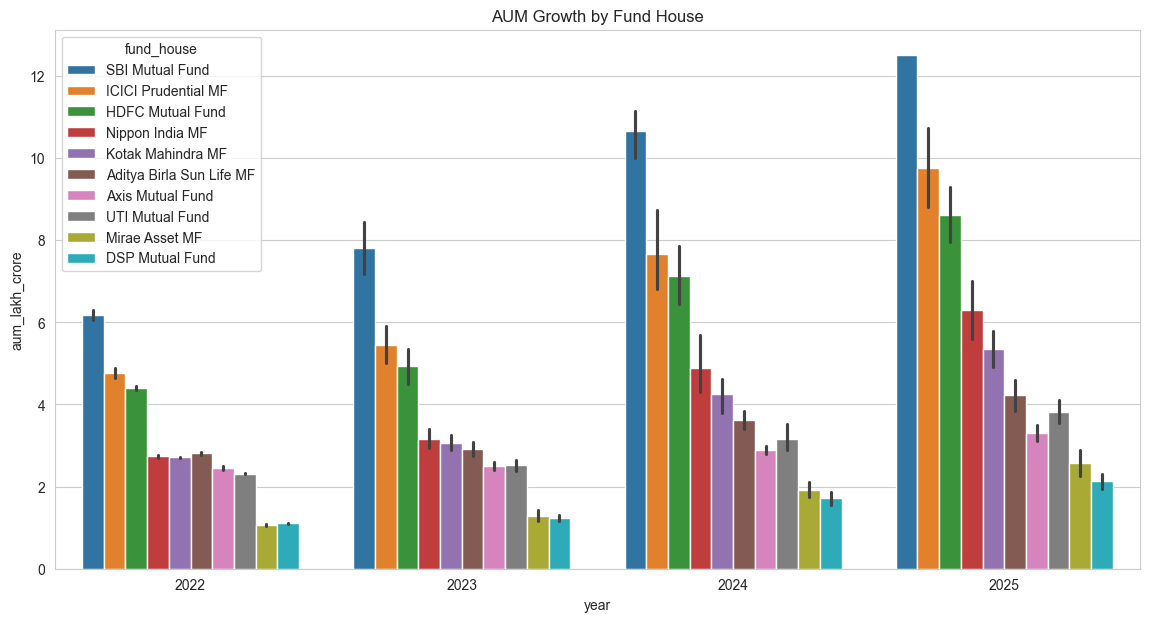

In [7]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title(
    "AUM Growth by Fund House"
)

plt.xticks(rotation=0)

plt.show()

In [8]:
sbi = aum[
    aum["fund_house"] ==
    "SBI Mutual Fund"
]

print(
    sbi["aum_lakh_crore"].max()
)

12.5


Insight : SBI Mutual Fund maintained the highest AUM among all fund houses, reaching approximately ₹12.5 lakh crore.

In [9]:
sip["month"] = pd.to_datetime(
    sip["month"]
)



In [10]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Peak ₹{max_row['sip_inflow_crore']} Cr"
)

fig.show()

Insight : Monthly SIP inflows reached an all-time high in December 2025, reflecting strong retail participation.

Task - 4 : 

In [11]:
heatmap_data = (
    cat.pivot(
        index="category",
        columns="month",
        values="net_inflow_crore"
    )
)

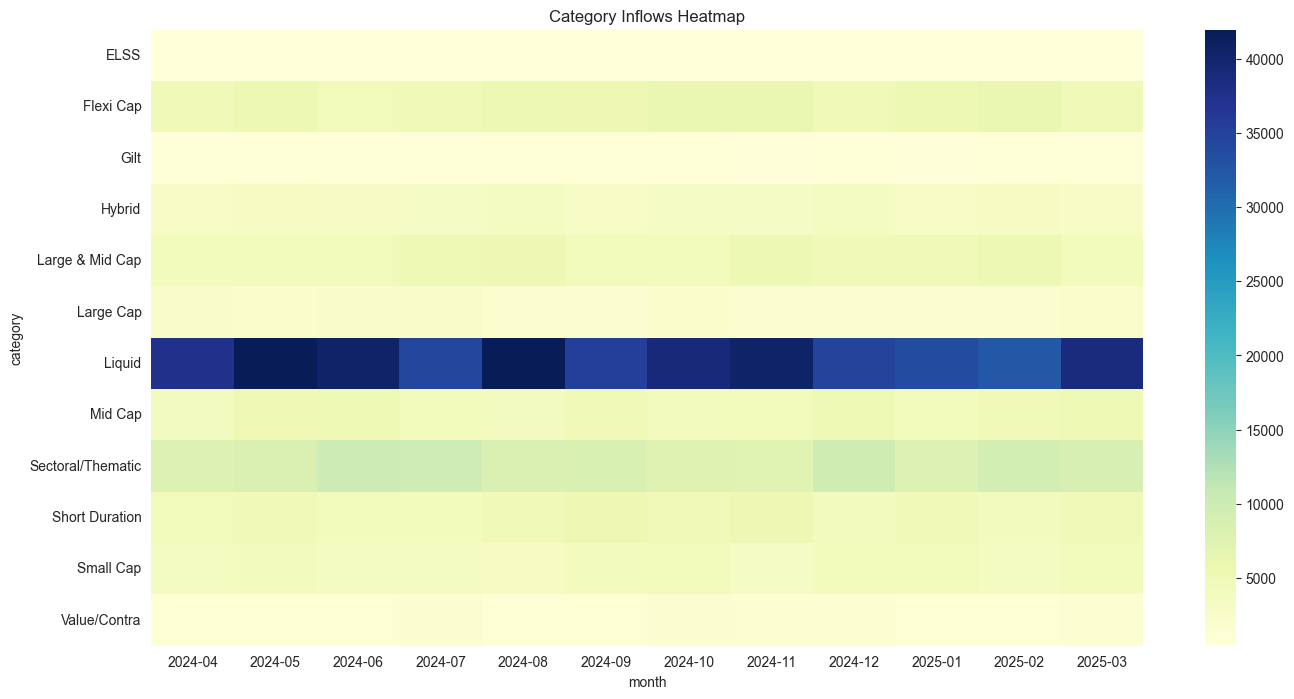

In [12]:
plt.figure(
    figsize=(16,8)
)

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title(
    "Category Inflows Heatmap"
)

plt.show()

Insight : Liquid categories consistently attracted higher inflows than traditional categories.

Task - 5 : 

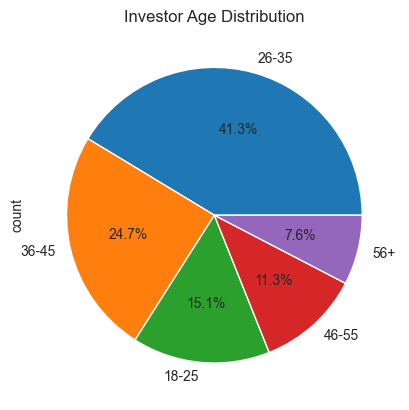

In [13]:
tx["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "Investor Age Distribution"
)

plt.show()

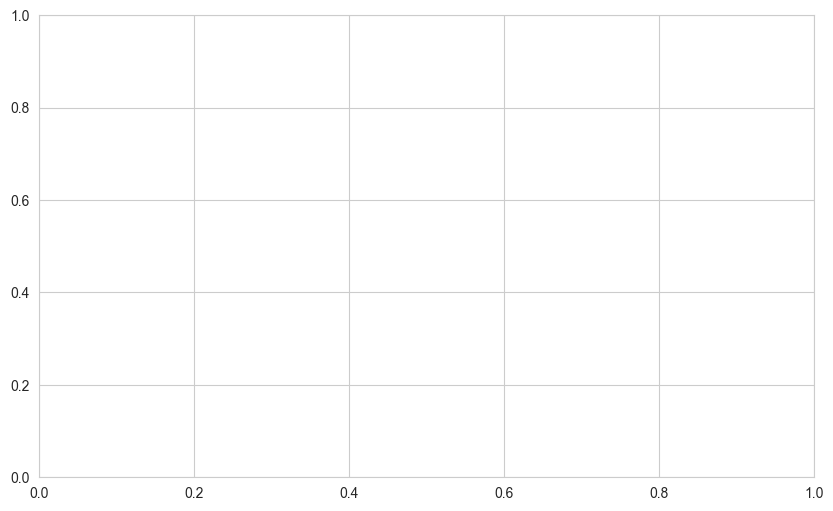

In [14]:
sip_tx = tx[
    tx["transaction_type"]=="SIP"
]

plt.figure(
    figsize=(10,6)
)

sns.boxplot(
    data=sip_tx,
    x="age_group",
    y="amount_inr"
)

plt.show()

Insight : The 26–45 age groups contributed the majority of SIP investments.

Task - 6 : 

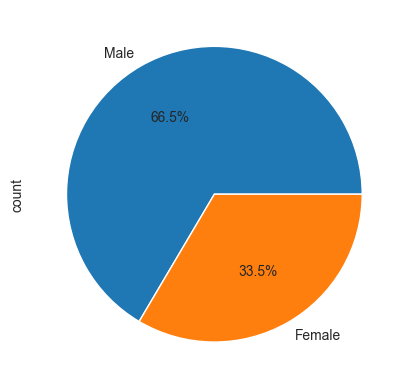

In [15]:
tx["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.show()

Insight : Male investors formed a larger proportion of transactions compared to female investors.

Task - 7 : 

In [16]:
state_data = (
    tx.groupby("state")["amount_inr"]
      .sum()
      .sort_values(
          ascending=False
      )
      .head(15)
)

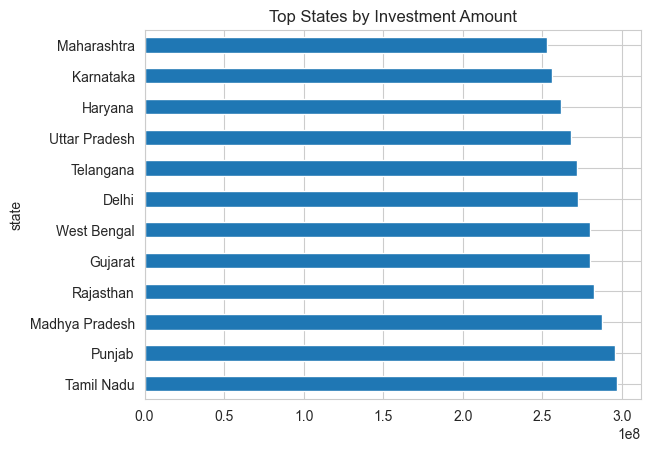

In [17]:
state_data.plot(
    kind="barh"
)

plt.title(
    "Top States by Investment Amount"
)

plt.show()

Insight : TamilNadu, Punjab, Madhya Pradesh, Rajasthan contributed a significant share of investment flows.

Task - 8 : 

<Axes: ylabel='count'>

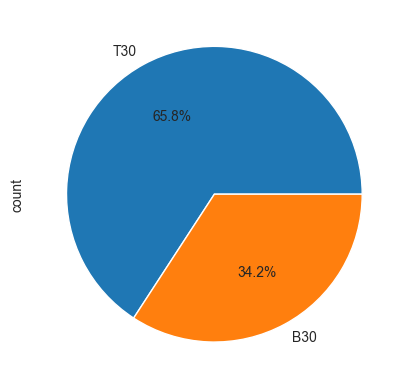

In [18]:
tx["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

Insight : T30 cities continue to dominate mutual fund investments, though B30 participation remains substantial.

Task - 9 : 

In [19]:
folios["month"] = pd.to_datetime(
    folios["month"]
)

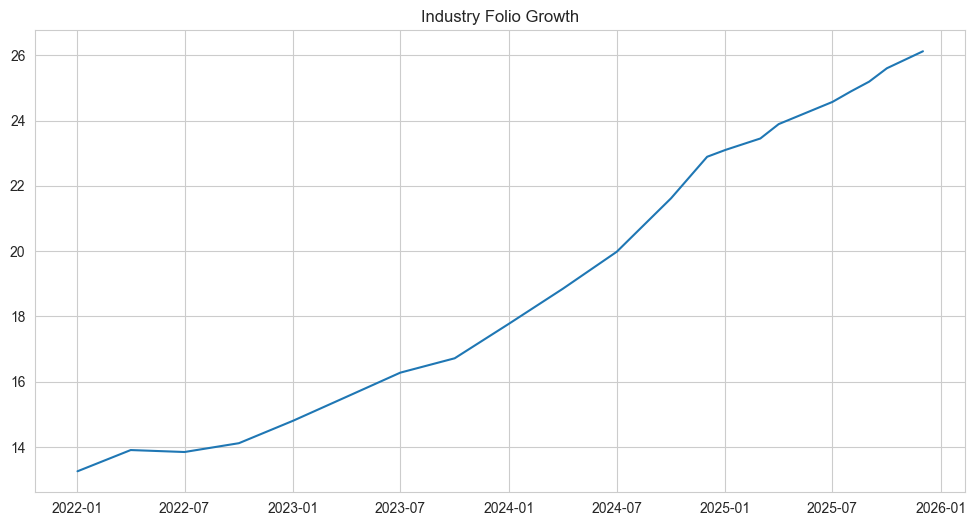

In [20]:
plt.figure(
    figsize=(12,6)
)

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title(
    "Industry Folio Growth"
)

plt.show()

Insight : Industry folios nearly doubled from approximately 13 crore to over 26 crore, highlighting increasing investor adoption.

Task - 10 : 

In [21]:
fund_list = (
    nav["amfi_code"]
    .unique()[:10]
)

In [22]:
corr_df = (
    nav[
        nav["amfi_code"]
        .isin(fund_list)
    ]
    .pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
)

returns = corr_df.pct_change()

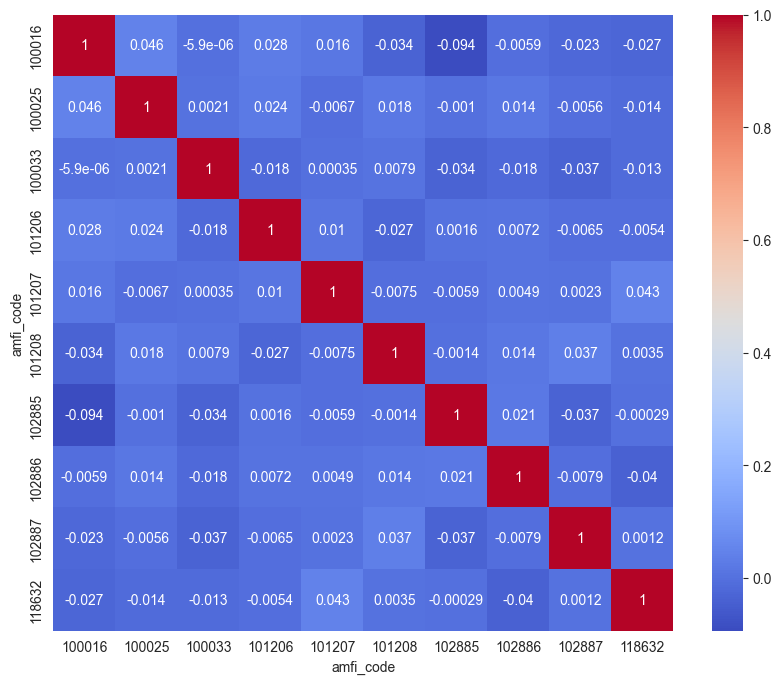

In [23]:
plt.figure(
    figsize=(10,8)
)

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Insight : Large-cap funds showed near zero correlations, indicating similar exposure to broad market movements.

Task - 11 : 

In [24]:
sector_alloc = (
    holdings.groupby("sector")
    ["weight_pct"]
    .sum()
    .sort_values(
        ascending=False
    )
)

In [25]:
fig = px.pie(
    values=sector_alloc.values,
    names=sector_alloc.index,
    hole=0.5
)

fig.show()

In [26]:
plt.savefig(
    "../reports/chart_01.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>